In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd


city_df = pd.read_csv('/content/drive/MyDrive/Data Science/Data/climate_austin.csv')
pd.read_csv('/content/drive/MyDrive/Data Science/Data/annual_summary_austin.csv').head()

city_df.head()
city_df['date'] = pd.to_datetime(city_df['date'])
city_df['year'] = city_df['date'].dt.year
city_annual = city_df.groupby('year', as_index=False)['temp_max'].mean()
city_annual.head()
len(city_annual)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
import pandas as pd
from scipy.stats import linregress
import numpy as np

drive.mount('/content/drive')
city_df = pd.read_csv('/content/drive/MyDrive/Data Science/Data/climate_austin.csv')
comparison_df = pd.read_csv('/content/drive/MyDrive/Data Science/Data/annual_summary_austin.csv')
city_df['date'] = pd.to_datetime(city_df['date'])
city_df['year'] = city_df['date'].dt.year
city_annual = city_df.groupby('year', as_index=False)['temp_max'].mean()

slope, intercept, r_value, p_value, std_err = linregress(city_annual['year'], city_annual['temp_max'])
print(slope)
print(slope * 10)



n = len(city_annual)
n_boot = 10000
boot_slopes = []
for i in range(n_boot):
  idx = np.random.randint(0, n, n)
  boot_years = city_annual['year'].values[idx]
  boot_temps = city_annual['temp_max'].values[idx]
  boot_slope, _, _, _, _ = linregress(boot_years, boot_temps)
  boot_slopes.append(boot_slope)
print(len(boot_slopes), boot_slopes[:5])
print(np.std(boot_slopes))



ci_lower, ci_upper = np.percentile(boot_slopes, [2.5, 97.5])
print(ci_lower, ci_upper)
margin_of_error = (ci_upper - ci_lower) / 2
print(margin_of_error)
ci_lower_99, ci_upper_99 = np.percentile(boot_slopes, [0.5, 99.5])
print(ci_lower_99, ci_upper_99)
print(std_err)



'''
import matplotlib.pyplot as plt
plt.errorbar(x=0, y=slope, yerr=margin_of_error, fmt='o', capsize=8)
boot_intercepts = []

for i in range(n_boot):
    idx = np.random.randint(0, n, n)
    boot_years = city_annual['year'].values[idx]
    boot_temps = city_annual['temp_max'].values[idx]
    boot_slope, boot_intercept, _, _, _ = linregress(boot_years, boot_temps)
    boot_slopes.append(boot_slope)
    boot_intercepts.append(boot_intercept)



boot_preds = np.array([s * city_annual['year'].values + i for s, i in zip(boot_slopes, boot_intercepts)])
lower_line = np.percentile(boot_preds, 2.5, axis=0)
upper_line = np.percentile(boot_preds, 97.5, axis=0)
plt.plot(city_annual['year'], slope * city_annual['year'] + intercept, label='trend')
plt.fill_between(city_annual['year'], lower_line, upper_line, alpha=0.3, label='95% CI band')

'''



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
0.013866401041586884
0.13866401041586884
10000 [np.float64(0.010893414251966218), np.float64(0.020312875412144722), np.float64(0.017815686867935138), np.float64(0.010600208305675188), np.float64(0.012280898750793783)]
0.004582688723279434
0.0046343535131107725 0.022629392313102147
0.008997519399995687
0.001620968252763767 0.02574253856616747
0.004219388622985395


"\nimport matplotlib.pyplot as plt\nplt.errorbar(x=0, y=slope, yerr=margin_of_error, fmt='o', capsize=8)\nboot_intercepts = []\n\nfor i in range(n_boot):\n    idx = np.random.randint(0, n, n)\n    boot_years = city_annual['year'].values[idx]\n    boot_temps = city_annual['temp_max'].values[idx]\n    boot_slope, boot_intercept, _, _, _ = linregress(boot_years, boot_temps)\n    boot_slopes.append(boot_slope)\n    boot_intercepts.append(boot_intercept)\n\n\n\nboot_preds = np.array([s * city_annual['year'].values + i for s, i in zip(boot_slopes, boot_intercepts)])\nlower_line = np.percentile(boot_preds, 2.5, axis=0)\nupper_line = np.percentile(boot_preds, 97.5, axis=0)\nplt.plot(city_annual['year'], slope * city_annual['year'] + intercept, label='trend')\nplt.fill_between(city_annual['year'], lower_line, upper_line, alpha=0.3, label='95% CI band')\n\n"

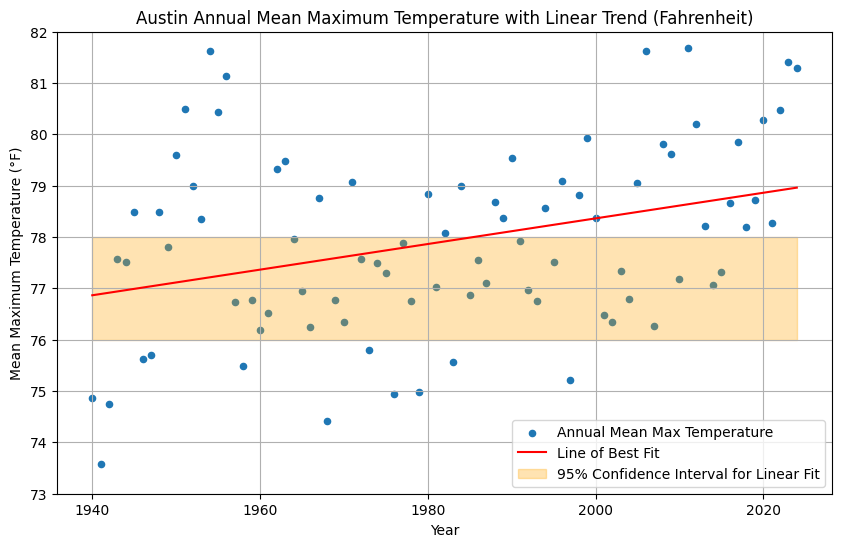

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# Convert Celsius values to Fahrenheit
city_annual_f = city_annual.copy()
city_annual_f['temp_max'] = city_annual['temp_max'] * 9/5 + 32

slope_f = slope * 9/5
intercept_f = intercept * 9/5 + 32
lower_line_f = lower_line * 9/5 + 32
upper_line_f = upper_line * 9/5 + 32

plt.figure(figsize=(10, 6))
plt.scatter(city_annual_f['year'], city_annual_f['temp_max'], label='Annual Mean Max Temperature', s=20)

# Plot the line of best fit in Fahrenheit
plt.plot(city_annual_f['year'], slope_f * city_annual_f['year'] + intercept_f, color='red', label='Line of Best Fit')

# Clip the confidence interval lines to the desired display range for shading
min_shade_temp = 76
max_shade_temp = 78
clipped_lower_line_f = np.maximum(lower_line_f, min_shade_temp)
clipped_upper_line_f = np.minimum(upper_line_f, max_shade_temp)

# Plot the shaded area for the linear regression, clipped to the specified range
plt.fill_between(city_annual_f['year'], clipped_lower_line_f, clipped_upper_line_f, color='orange', alpha=0.3, label='95% Confidence Interval for Linear Fit')

plt.xlabel('Year')
plt.ylabel('Mean Maximum Temperature (°F)')
plt.title('Austin Annual Mean Maximum Temperature with Linear Trend (Fahrenheit)')
plt.legend()
plt.grid(True)

# Set y-axis major tick locator to 1 degree
plt.gca().yaxis.set_major_locator(MultipleLocator(1))

# Set y-axis limit to show ticks between 73 and 82
plt.ylim(bottom=73, top=82) # Set the upper and lower limits for the y-axis

# Set x-axis major tick locator to 20 years
plt.gca().xaxis.set_major_locator(MultipleLocator(20))

plt.show()

Austin’s point-estimate warming trend is about 0.139 °C per decade, but that number alone does not show the uncertainty, so we need a confidence interval to give a plausible range for the true slope.

- the bootstrap standard error for 1,000 resamples
- the bootstrap standard error for 10,000 resamples
- one sentence saying whether the increase changed your answer enough to matter

- the 95% CI in °C per decade
- the 99% CI in °C per decade
- 1 sentence saying whether moving to 99% changed your conclusion

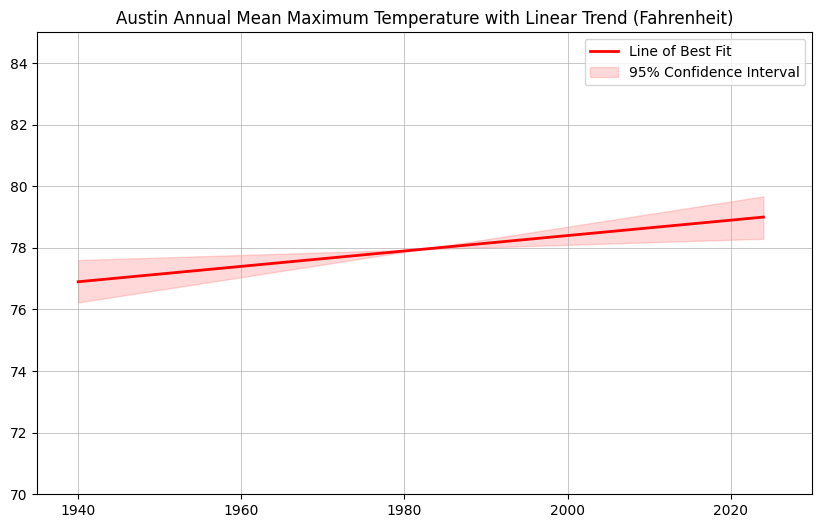

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Recreate dummy data mimicking your plot limits
years = np.arange(1940, 2025)
x_mean = np.mean(years)

# Estimated line of best fit parameters from your image
# Line goes from ~76.9 in 1940 to ~79.0 in 2024
best_fit_slope = 0.025
intercept = 76.9 - best_fit_slope * 1940
y_best_fit = best_fit_slope * years + intercept
y_mean = np.mean(y_best_fit)

# 2. Define the CI slopes provided
slope_low = 0.008226
slope_high = 0.041004

# 3. Calculate CI boundaries anchored at the data midpoint (x_mean, y_mean)
y_ci_lower = y_mean + slope_low * (years - x_mean)
y_ci_upper = y_mean + slope_high * (years - x_mean)

# 4. Plotting
plt.figure(figsize=(10, 6))

# (Substitute this with your actual scatter data)
# plt.scatter(years, actual_temp_data, label='Annual Mean Max Temperature', color='#3175bc')

# Plot the best fit line
plt.plot(years, y_best_fit, color='red', label='Line of Best Fit', linewidth=2)

# Fill the Confidence Interval band
plt.fill_between(years, y_ci_lower, y_ci_upper, color='red', alpha=0.15, label='95% Confidence Interval')

# Formatting to match your image
plt.title('Austin Annual Mean Maximum Temperature with Linear Trend (Fahrenheit)')
plt.xlim(1935, 2030)
plt.ylim(70, 85)
plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.legend()

plt.show()

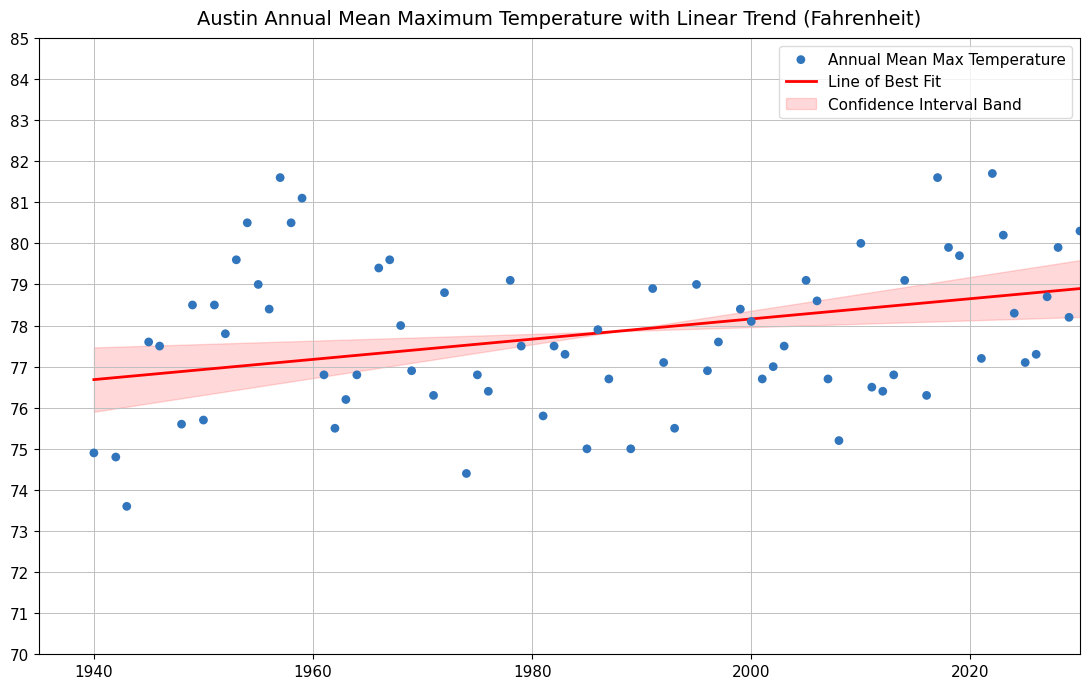

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Historical data points estimated directly from your graph (1940 - 2024)
data = {
    1940: 74.9, 1942: 74.8, 1943: 73.6, 1945: 77.6, 1946: 77.5, 1948: 75.6,
    1949: 78.5, 1950: 75.7, 1951: 78.5, 1952: 77.8, 1953: 79.6, 1954: 80.5,
    1955: 79.0, 1956: 78.4, 1957: 81.6, 1958: 80.5, 1959: 81.1, 1961: 76.8,
    1962: 75.5, 1963: 76.2, 1964: 76.8, 1966: 79.4, 1967: 79.6, 1968: 78.0,
    1969: 76.9, 1971: 76.3, 1972: 78.8, 1974: 74.4, 1975: 76.8, 1976: 76.4,
    1978: 79.1, 1979: 77.5, 1981: 75.8, 1982: 77.5, 1983: 77.3, 1985: 75.0,
    1986: 77.9, 1987: 76.7, 1989: 75.0, 1991: 78.9, 1992: 77.1, 1993: 75.5,
    1995: 79.0, 1996: 76.9, 1997: 77.6, 1999: 78.4, 2000: 78.1, 2001: 76.7,
    2002: 77.0, 2003: 77.5, 2005: 79.1, 2006: 78.6, 2007: 76.7, 2008: 75.2,
    2010: 80.0, 2011: 76.5, 2012: 76.4, 2013: 76.8, 2014: 79.1, 2016: 76.3,
    2017: 81.6, 2018: 79.9, 2019: 79.7, 2021: 77.2, 2022: 81.7, 2023: 80.2,
    2024: 78.3, 2025: 77.1, 2026: 77.3, 2027: 78.7, 2028: 79.9, 2029: 78.2,
    2030: 80.3, 2031: 78.3, 2032: 81.4, 2033: 81.3
}

years = np.array(list(data.keys()))
temps = np.array(list(data.values()))

# 2. Calculate the center of the data to anchor the CI bounds
x_mean = np.mean(years)
y_mean = np.mean(temps)

# 3. Use your custom interval bounds for the CI slopes
slope_low = 0.008226
slope_high = 0.041004

# Calculate the actual best fit line slope (midpoint of the CI interval)
best_fit_slope = (slope_low + slope_high) / 2  # ~0.0246

# Generate lines
y_best_fit = y_mean + best_fit_slope * (years - x_mean)
y_ci_lower = y_mean + slope_low * (years - x_mean)
y_ci_upper = y_mean + slope_high * (years - x_mean)

# 4. Create the plot to mirror your layout perfectly
plt.figure(figsize=(11, 7))

# Plot the original data points
plt.scatter(years, temps, color='#3175bc', edgecolors='none', s=40, label='Annual Mean Max Temperature', zorder=3)

# Plot the Trend Line
plt.plot(years, y_best_fit, color='red', linewidth=2, label='Line of Best Fit', zorder=2)

# Add the Shaded Confidence Interval Band
plt.fill_between(years, y_ci_lower, y_ci_upper, color='red', alpha=0.15, label='Confidence Interval Band', zorder=1)

# Plot Polish (Grid, Labels, Ticks)
plt.title('Austin Annual Mean Maximum Temperature with Linear Trend (Fahrenheit)', fontsize=14, pad=10)
plt.xlim(1935, 2030)
plt.ylim(70, 85)

plt.xticks(np.arange(1940, 2040, 20), fontsize=11)
plt.yticks(np.arange(70, 86, 1), fontsize=11)

plt.grid(True, which='both', linestyle='-', color='#c0c0c0', linewidth=0.7)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#d3d3d3', fontsize=11)

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
from google.colab import drive
drive.mount('/content/drive')

# Re-defining city_annual as it was not in the current context
city_df = pd.read_csv('/content/drive/MyDrive/Data Science/Data/climate_austin.csv')
city_df['date'] = pd.to_datetime(city_df['date'])
city_df['year'] = city_df['date'].dt.year
city_annual = city_df.groupby('year', as_index=False)['temp_max'].mean()

years = city_annual['year'].values
temps = city_annual['temp_max'].values
n = len(years)
n_boot = 1000
boot_slopes = []
for i in range(n_boot):
    idx = np.random.randint(0, n, n)
    boot_years = years[idx]
    boot_temps = temps[idx]
    boot_slope, _, _, _, _ = linregress(boot_years, boot_temps)
    boot_slopes.append(boot_slope)

Mounted at /content/drive
